In [ ]:
from sklearn.datasets import load_iris
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


# Load Iris dataset
iris = load_iris()

# Create DataFrame
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Add species column
df['species'] = iris.target

# Display first 5 rows
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  


Accuracy: 1.0


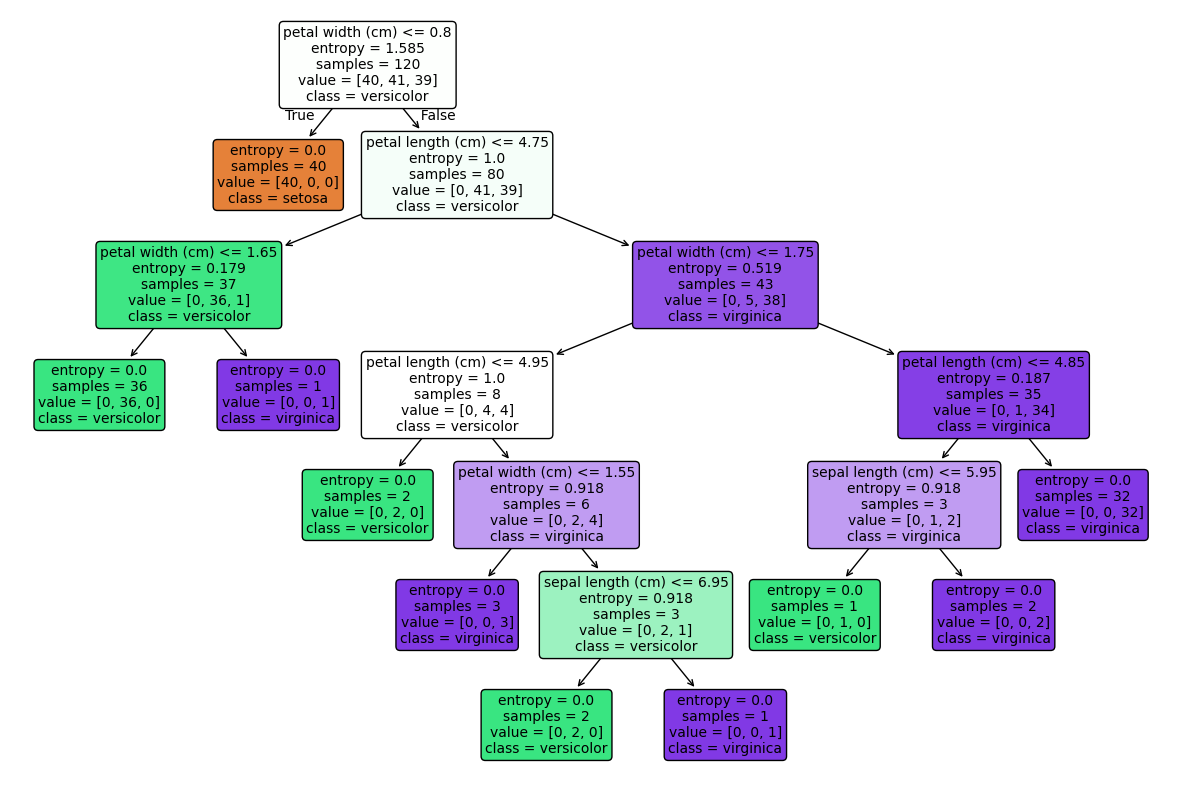

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

X = iris.data
y = iris.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = DecisionTreeClassifier(criterion='entropy')
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Display the tree
plt.figure(figsize=(15,10))

plot_tree(
    model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.show()




In [ ]:
#categorical dataset
import seaborn as sns
df = sns.load_dataset('titanic')
print(df.head())

import seaborn as sns
df = sns.load_dataset('titanic')
df = df[['sex', 'class', 'embark_town', 'alone', 'survived']]
print(df.head())



   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
      sex  class  embark_town  alone  survived
0    male  Third  Southampton  False         0
1  female  First    Cherbourg  False         1
2  female  Third  Southampton   True         1
3  female  First  Southampton  

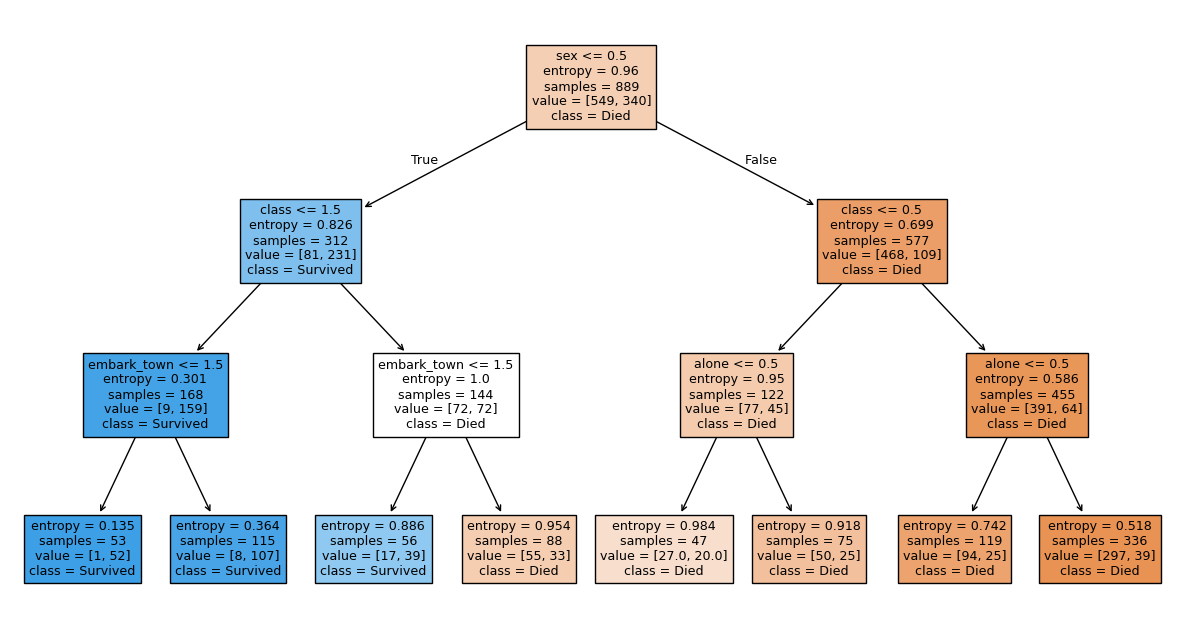

In [ ]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Load data
df = sns.load_dataset('titanic')

# Select categorical features
df = df[['sex', 'class', 'embark_town', 'alone', 'survived']]

# Remove missing values
df = df.dropna()

# Encode categorical columns
le = LabelEncoder()

for col in ['sex', 'class', 'embark_town', 'alone']:
    df[col] = le.fit_transform(df[col]) #Learns the unique categories and assigns numbers
    # required for scikit learn

# Features and target
X = df[['sex', 'class', 'embark_town', 'alone']]
y = df['survived']

# Train tree
#model = DecisionTreeClassifier(criterion='entropy')
#model.fit(X, y)


model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=3,
    random_state=42
)
model.fit(X, y)

# Visualize tree
plt.figure(figsize=(15,8))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=['Died', 'Survived'],
    filled=True
)

plt.show()